<a href="https://colab.research.google.com/github/blbl-blbl/study/blob/main/PyTorch/01_oxford_pets/06_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/blbl-blbl/study/blob/main/PyTorch/01_oxford_pets/06_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oxford-IIIT Pet — Data Augmentation

Текущая тема курса: мягкие train-аугментации (`RandomResizedCrop`, `RandomHorizontalFlip`) при неизменной validation-preprocessing и отдельные DataLoader.

> Этот notebook самодостаточен: его можно запускать сверху вниз в чистом Google Colab. Он не требует выполнения других notebook-файлов проекта.

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

raw_dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    download=True,
)

labels = np.array([raw_dataset[i][1] for i in range(len(raw_dataset))])

train_indices, val_indices = train_test_split(
    np.arange(len(raw_dataset)),
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

class_names = raw_dataset.classes
weights = ResNet18_Weights.IMAGENET1K_V1
resnet_transform = weights.transforms()

resnet_train_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_transform,
    download=False,
)

resnet_val_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_transform,
    download=False,
)

resnet_train_dataset = Subset(resnet_train_source, train_indices.tolist())
resnet_val_dataset = Subset(resnet_val_source, val_indices.tolist())

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42),
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

loss_fn = nn.CrossEntropyLoss()

print("Train:", len(resnet_train_dataset))
print("Validation:", len(resnet_val_dataset))
print("Classes:", len(class_names))


Device: cuda


100%|██████████| 792M/792M [00:32<00:00, 24.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


Train: 2944
Validation: 736
Classes: 37


In [2]:
# Функция обучения
def train_head_one_epoch(
    model, dataloader, loss_fn, optimizer, device
):
  model.eval()
  model.fc.train()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = labels.size(0)
    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  return (
      total_loss / total_objects,
      total_correct / total_objects
  )


  # Функция оценки
def evaluate_metrics(model, dataloader, loss_fn, device, num_classes):
  model.eval()

  total_loss = 0.0
  total_correct = 0
  total_top3_correct = 0
  total_objects = 0

  all_labels = []
  all_predictions = []

  with torch.inference_mode():
      for images, labels in dataloader:
          images = images.to(device)
          labels = labels.to(device)

          logits = model(images)
          loss = loss_fn(logits, labels)

          predictions = logits.argmax(dim=1)
          top3 = logits.topk(k=3, dim=1).indices

          batch_size = labels.size(0)

          total_loss += loss.item() * batch_size
          total_correct += (predictions == labels).sum().item()
          total_top3_correct += (
              (top3 == labels.unsqueeze(1))
              .any(dim=1)
              .sum()
              .item()
          )
          total_objects += batch_size

          all_labels.extend(labels.cpu().tolist())
          all_predictions.extend(predictions.cpu().tolist())

  macro_f1 = f1_score(
      all_labels,
      all_predictions,
      labels=list(range(num_classes)),
      average="macro",
      zero_division=0,
  )

  return {
      "loss": total_loss / total_objects,
      "accuracy": total_correct / total_objects,
      "macro_f1": macro_f1,
      "top3_accuracy": total_top3_correct / total_objects,
  }

In [3]:
# Базовая модель
seed_everything(42)
resnet_train_loader.generator.manual_seed(42)

resnet_model = resnet18(weights=weights)

for parameter in resnet_model.parameters():
  parameter.requires_grad = False

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    len(class_names),
)

resnet_model = resnet_model.to(device)

# Передаем оптимизатору только параметры последнего слоя
resnet_optimizer = torch.optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001,
)
loss_fn = nn.CrossEntropyLoss()

resnet_checkpoint_path = Path(
    "checkpoints/resnet18_head.pth"
)

resnet_checkpoint_path.parent.mkdir(
    parents=True, exist_ok=True
)

resnet_history = []

best_macro_f1 = -float("inf")
best_epoch = None
epochs_without_improvement = 0

max_epochs = 15
patience = 3
min_delta = 1e-4

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_head_one_epoch(
      resnet_model,
      resnet_train_loader,
      loss_fn,
      resnet_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      resnet_model,
      resnet_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  resnet_history.append({
      'epoch': epoch,
      'train_loss': train_loss,
      'train_accuracy': train_accuracy,
      'val_loss': metrics["loss"],
      'val_accuracy': metrics['accuracy'],
      'val_macro_f1': metrics['macro_f1'],
      'val_top3_accuracy': metrics['top3_accuracy'],
  })

  status = ""

  if metrics['macro_f1'] > best_macro_f1 + min_delta:
    best_macro_f1 = metrics['macro_f1']
    best_epoch = epoch
    epochs_without_improvement = 0

    torch.save({
        'model_state_dict': resnet_model.state_dict(),
        'epoch': epoch,
        'metrics': metrics,
        'class_names': class_names,
        'weights': 'IMAGENET1K_V1',
    }, resnet_checkpoint_path)

    status = 'saved'

  else:
    epochs_without_improvement += 1
    status = (
        f"No improvement: "
        f"{epochs_without_improvement}/{patience}"
    )

  print(
      f"Epoch {epoch}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.2%} | "
      f"Val macro-F1: {metrics['macro_f1']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


Epoch 1/15 | Train loss: 1.8055 | Train accuracy: 60.70% | Val loss: 0.8145 | Val accuracy: 86.41% | Val macro-F1: 0.8609 | saved
Epoch 2/15 | Train loss: 0.5829 | Train accuracy: 89.61% | Val loss: 0.5030 | Val accuracy: 89.95% | Val macro-F1: 0.8996 | saved
Epoch 3/15 | Train loss: 0.3822 | Train accuracy: 92.70% | Val loss: 0.4020 | Val accuracy: 90.08% | Val macro-F1: 0.9011 | saved
Epoch 4/15 | Train loss: 0.2926 | Train accuracy: 94.29% | Val loss: 0.3547 | Val accuracy: 90.08% | Val macro-F1: 0.9008 | No improvement: 1/3
Epoch 5/15 | Train loss: 0.2381 | Train accuracy: 95.75% | Val loss: 0.3170 | Val accuracy: 91.58% | Val macro-F1: 0.9163 | saved
Epoch 6/15 | Train loss: 0.1986 | Train accuracy: 96.33% | Val loss: 0.3157 | Val accuracy: 91.17% | Val macro-F1: 0.9117 | No improvement: 1/3
Epoch 7/15 | Train loss: 0.1695 | Train accuracy: 97.11% | Val loss: 0.2867 | Val accuracy: 91.71% | Val macro-F1: 0.9173 | saved
Epoch 8/15 | Train loss: 0.1472 | Train accuracy: 97.62% | Val

## Мягкая аугментация только для train

Validation остаётся детерминированной. Это позволяет проверять эффект аугментации, не меняя способ оценки модели.

In [4]:
resnet_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Validation-преобразования оставим прежними и детерменированными
resnet_val_transform = weights.transforms()

In [5]:
aug_train_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_train_transform,
    download=False,
)

aug_val_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_val_transform,
    download=False,
)


aug_train_dataset = Subset(
    aug_train_source,
    train_indices.tolist()
)

aug_val_dataset = Subset(
    aug_val_source,
    val_indices.tolist()
)


aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42)
)

aug_val_loader = DataLoader(
    aug_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

### Визуальная проверка

После нормализации изображения выглядят неправильно, если показать их через `imshow`. Поэтому сначала выполним обратную нормализацию

Проверяем несколько изображений после случайных преобразований. При повторном запуске ячейки аугментации могут отличаться — это ожидаемо.

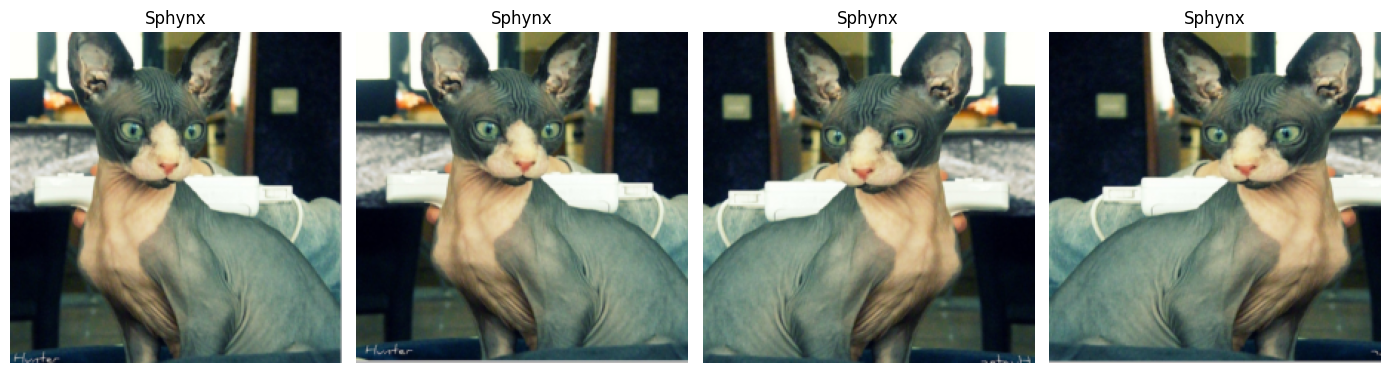

In [6]:
import matplotlib.pyplot as plt

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

sample_index = int(train_indices[0])

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax in axes:
  image, label = aug_train_source[sample_index]

  visible_image = image * std + mean
  visible_image = visible_image.clamp(0, 1)
  visible_image = visible_image.permute(1, 2, 0)

  ax.imshow(visible_image)
  ax.set_title(class_names[label])
  ax.axis('off')

plt.tight_layout()
plt.show()

Это четыре обращения к одной и той же исходной фотографии. Из-за `RandomResizedCrop` и `RandomHorizontalFlip` варианты должны отличаться:
  * масштабом
  * положением объекта в кадре
  * иногда горизонтальным отражением

Небольшие части животного могут обрезаться - это нормально. Но если животное регулярно почти полностью исчезает, диапазон crop слишком агрессивный


### Проверяем батч

In [7]:
images, labels = next(iter(aug_train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Labels dtype: torch.int64


### Повторяем head-only эксперимент

Создаем модель заново с исходными ImageNet-весами. Не загружаем checkpoint 11-й эпохи, потому что хотим изменить только одну переменную эксперимента - train-аугментацию

In [8]:
seed_everything(42)
aug_train_loader.generator.manual_seed(42)

aug_model = resnet18(weights=weights)

for parameter in aug_model.parameters():
  parameter.requires_grad = False

aug_model.fc = nn.Linear(
    aug_model.fc.in_features,
    len(class_names),
)

aug_model = aug_model.to(device)

aug_optimizer = torch.optim.Adam(
    aug_model.fc.parameters(),
    lr=0.001,
)

aug_checkpoint_path = Path(
    "checkpoints/resnet18_head_augmented.pth",
)

aug_checkpoint_path.parent.mkdir(
    parents=True, exist_ok=True
)

aug_history = []

best_macro_f1 = -float('inf')
best_epoch = None
epochs_without_improvement = 0

max_epochs = 15
patience = 3
min_delta = 1e-4

for epoch in range(1, max_epochs + 1):
  train_loss, train_accuracy = train_head_one_epoch(
      aug_model,
      aug_train_loader,
      loss_fn,
      aug_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      aug_model,
      aug_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  aug_history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "train_accuracy": train_accuracy,
      "val_loss": metrics["loss"],
      "val_accuracy": metrics["accuracy"],
      "val_macro_f1": metrics["macro_f1"],
      "val_top3_accuracy": metrics["top3_accuracy"],
  })

  if metrics["macro_f1"] > best_macro_f1 + min_delta:
    best_macro_f1 = metrics["macro_f1"]
    best_epoch = epoch
    epochs_without_improvement = 0
    status = "saved"

    torch.save(
        {
            "model_state_dict": aug_model.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "class_names": class_names,
            "weights": "IMAGENET1K_V1",
            "augmentation": True,
        },
        aug_checkpoint_path
    )

  else:
    epochs_without_improvement += 1
    status = (
        f"No improvement: "
        f"{epochs_without_improvement}/{patience}"
    )

  print(
    f"Epoch {epoch}/{max_epochs} | "
    f"Train loss: {train_loss:.4f} | "
    f"Train accuracy: {train_accuracy:.2%} | "
    f"Val loss: {metrics['loss']:.4f} | "
    f"Val accuracy: {metrics['accuracy']:.2%} | "
    f"Val macro-F1: {metrics['macro_f1']:.4f} | "
    f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break


Epoch 1/15 | Train loss: 1.8558 | Train accuracy: 58.49% | Val loss: 0.8289 | Val accuracy: 84.24% | Val macro-F1: 0.8371 | saved
Epoch 2/15 | Train loss: 0.6337 | Train accuracy: 88.49% | Val loss: 0.5153 | Val accuracy: 89.27% | Val macro-F1: 0.8923 | saved
Epoch 3/15 | Train loss: 0.4180 | Train accuracy: 91.37% | Val loss: 0.4076 | Val accuracy: 90.22% | Val macro-F1: 0.9020 | saved
Epoch 4/15 | Train loss: 0.3256 | Train accuracy: 93.31% | Val loss: 0.3572 | Val accuracy: 90.76% | Val macro-F1: 0.9075 | saved
Epoch 5/15 | Train loss: 0.2686 | Train accuracy: 93.99% | Val loss: 0.3242 | Val accuracy: 90.49% | Val macro-F1: 0.9055 | No improvement: 1/3
Epoch 6/15 | Train loss: 0.2285 | Train accuracy: 94.50% | Val loss: 0.3259 | Val accuracy: 91.58% | Val macro-F1: 0.9165 | saved
Epoch 7/15 | Train loss: 0.2055 | Train accuracy: 95.82% | Val loss: 0.2889 | Val accuracy: 92.12% | Val macro-F1: 0.9216 | saved
Epoch 8/15 | Train loss: 0.1751 | Train accuracy: 96.64% | Val loss: 0.2819 

## Следующий контролируемый эксперимент

Теперь проверим, помогает ли аугментация именно при fine-tune `layer4`. Начнем с того же исходного checkpoint без аугментации, что и в предыдущем fine-tuning. Единственное изменение - `aug_train_loader`

In [16]:
seed_everything(42)
aug_train_loader.generator.manual_seed(42)

head_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location='cpu',
    weights_only=True,
)

aug_fine_tune_model = resnet18(weights=None)

aug_fine_tune_model.fc = nn.Linear(
    aug_fine_tune_model.fc.in_features,
    len(class_names)
)

aug_fine_tune_model.load_state_dict(
    head_checkpoint["model_state_dict"]
)

for parameter in aug_fine_tune_model.parameters():
  parameter.requires_grad=False

for parameter in aug_fine_tune_model.layer4.parameters():
  parameter.requires_grad=True

for parameter in aug_fine_tune_model.fc.parameters():
  parameter.requires_grad=True


aug_fine_tune_model = aug_fine_tune_model.to(device)

aug_fine_tune_optimizer = torch.optim.Adam([
    {
        "params": aug_fine_tune_model.layer4.parameters(),
        "lr": 1e-5,
    },
    {
        "params": aug_fine_tune_model.fc.parameters(),
        "lr": 1e-4,
    }
])


Проверим параметры:

In [17]:
trainable_names = [
    name
    for name, parameter
    in aug_fine_tune_model.named_parameters()
    if parameter.requires_grad
]

assert all(
    name.startswith(("layer4.", "fc."))
    for name in trainable_names
)

print("First:", trainable_names[0])
print("Last:", trainable_names[-1])

First: layer4.0.conv1.weight
Last: fc.bias


In [18]:
# Функция обучения для layer4 и fc
def train_layer4_one_epoch(
    model, dataloader, loss_fn, optimizer, device
):
  # Замороженная часть остается в eval
  model.eval()

  # Дообучаемые части переводим в train
  model.fc.train()
  model.layer4.train()

  total_loss = 0.0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = labels.size(0)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  return (
      total_loss / total_objects,
      total_correct / total_objects
  )


In [19]:
aug_fine_tune_checkpoint_path = Path(
    "checkpoints/resnet18_layer4_augmented.pth"
)

aug_fine_tune_history = []

best_macro_f1 = head_checkpoint["metrics"]["macro_f1"]
best_epoch = 0
epochs_without_improvement = 0

max_epochs = 15
patience = 3
min_delta = 1e-4

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_head_one_epoch(
      aug_fine_tune_model,
      aug_train_loader,
      loss_fn,
      aug_fine_tune_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      aug_fine_tune_model,
      aug_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  aug_fine_tune_history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "train_accuracy": train_accuracy,
      "val_loss": metrics["loss"],
      "val_accuracy": metrics["accuracy"],
      "val_macro_f1": metrics["macro_f1"],
      "val_top3_accuracy": metrics["top3_accuracy"],
  })

  if metrics['macro_f1'] > best_macro_f1 + min_delta:
    best_macro_f1 = metrics['macro_f1']
    best_epoch = epoch
    epochs_without_improvement = 0
    status = 'saved'

    torch.save(
        {
            "model_state_dict": aug_fine_tune_model.state_dict(),
            "optimizer_state_dict": aug_fine_tune_optimizer.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "class_names": class_names,
            "weights": "IMAGENET1K_V1",
            "stage": "layer4_fc_fine_tuning",
        },
        aug_fine_tune_checkpoint_path
    )

  else:
      epochs_without_improvement += 1
      status = (
          f"No improvement: "
          f"{epochs_without_improvement}/{patience}"
      )

  print(
      f"Epoch {epoch}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.2%} | "
      f"Val macro-F1: {metrics['macro_f1']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
      print("Early stopping")
      break

Epoch 1/15 | Train loss: 0.1213 | Train accuracy: 96.43% | Val loss: 0.2296 | Val accuracy: 93.75% | Val macro-F1: 0.9377 | saved
Epoch 2/15 | Train loss: 0.0817 | Train accuracy: 97.52% | Val loss: 0.2417 | Val accuracy: 92.26% | Val macro-F1: 0.9230 | No improvement: 1/3
Epoch 3/15 | Train loss: 0.0514 | Train accuracy: 98.91% | Val loss: 0.2667 | Val accuracy: 91.58% | Val macro-F1: 0.9160 | No improvement: 2/3
Epoch 4/15 | Train loss: 0.0390 | Train accuracy: 99.08% | Val loss: 0.2598 | Val accuracy: 92.53% | Val macro-F1: 0.9259 | No improvement: 3/3
Early stopping


## Контрольная загрузка checkpoint

In [20]:
best_aug_checkpoint = torch.load(
    aug_fine_tune_checkpoint_path,
    map_location=device,
    weights_only=True,
)

aug_fine_tune_model.load_state_dict(
    best_aug_checkpoint["model_state_dict"]
)

best_aug_metrics = evaluate_metrics(
    aug_fine_tune_model,
    aug_val_loader,
    loss_fn,
    device,
    num_classes=len(class_names),
)

print("Loaded epoch:", best_aug_checkpoint["epoch"])

for name, value in best_aug_metrics.items():
    print(f"{name}: {value:.4f}")

Loaded epoch: 1
loss: 0.2296
accuracy: 0.9375
macro_f1: 0.9377
top3_accuracy: 0.9878
